In [1]:
"""
Student Performance Analytics System
------------------------------------

Features:
- CSV file creation
- CSV file reading
- NumPy array operations
- Statistical analysis
- Data visualization

Libraries Used:
- NumPy
- Matplotlib

Dataset Format (students.csv):
--------------------------------
student_id,math,physics,programming
1,75,82,90
2,88,79,95
3,60,70,72
"""


'\nStudent Performance Analytics System\n------------------------------------\n\nFeatures:\n- CSV file creation\n- CSV file reading\n- NumPy array operations\n- Statistical analysis\n- Data visualization\n\nLibraries Used:\n- NumPy\n- Matplotlib\n\nDataset Format (students.csv):\n--------------------------------\nstudent_id,math,physics,programming\n1,75,82,90\n2,88,79,95\n3,60,70,72\n'

In [2]:
import csv
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Create student file

In [3]:
def create_student_file(filename:str, student_numbers:int) -> list[list[int]]:
    '''
    Creates a student data file containing random scores between 0, 100 for a user-defined number of students
    and three lessons: math, physics, programming.
    '''
    student_wdata = []
    for row in range(1, student_numbers + 1):
        list1 = []
        list1.append(row)
        for column in range(1, 4):
            list1.append(random.randint(0,100))
        student_wdata.append(list1)
    f1 = open(filename, 'w')
    c1 = csv.writer(f1)
    c1.writerow(['student_id', 'math', 'physics', 'programming'])
    c1.writerows(student_wdata)
    f1.close()
    return student_wdata

In [4]:
create_student_file('file_31.csv', 10)

[[1, 35, 1, 17],
 [2, 75, 27, 68],
 [3, 41, 80, 100],
 [4, 72, 95, 82],
 [5, 67, 80, 59],
 [6, 95, 30, 80],
 [7, 67, 41, 58],
 [8, 45, 15, 7],
 [9, 65, 55, 47],
 [10, 99, 20, 71]]

# 2. Load student data from text file

In [5]:
def read_data(filename: str) -> list[list[int]]:
    '''
    Loads a student scores table from a text file and returns a 2D list.
    '''
    f1 = open(filename, 'r')
    c1 = csv.reader(f1)
    student_rdata = []
    next(c1)
    for row in c1:
        if row != []:
            student_rdata.append(row)
    f1.close()
    return student_rdata

In [6]:
student_rdata = read_data('file_31.csv')

In [7]:
student_rdata

[['1', '35', '1', '17'],
 ['2', '75', '27', '68'],
 ['3', '41', '80', '100'],
 ['4', '72', '95', '82'],
 ['5', '67', '80', '59'],
 ['6', '95', '30', '80'],
 ['7', '67', '41', '58'],
 ['8', '45', '15', '7'],
 ['9', '65', '55', '47'],
 ['10', '99', '20', '71']]

# 3. Convert Student Data to Float

In [8]:
def convert_to_float(student_data: list[list[str]]) -> np.array:
    '''
    Converts student data which are read as strings to floats.
    '''
    student_rdata_float = []
    for row in student_data:
        list1 = []
        for x in row:
            x = float(x)
            list1.append(x)
        student_rdata_float.append(list1)
    return np.array(student_rdata_float)

In [9]:
student_rdata_float = convert_to_float(student_rdata)

In [10]:
student_rdata_float

array([[  1.,  35.,   1.,  17.],
       [  2.,  75.,  27.,  68.],
       [  3.,  41.,  80., 100.],
       [  4.,  72.,  95.,  82.],
       [  5.,  67.,  80.,  59.],
       [  6.,  95.,  30.,  80.],
       [  7.,  67.,  41.,  58.],
       [  8.,  45.,  15.,   7.],
       [  9.,  65.,  55.,  47.],
       [ 10.,  99.,  20.,  71.]])

# 4. Manual Mean Calculation

In [11]:
def man_mean(data:np.array) -> float:
    '''
    Calculates the mean value of a data array.
    '''
    sum = 0
    for x in data:
        sum = sum + x
    return sum / len(data)

In [12]:
man_mean(student_rdata_float[:, 1])

np.float64(66.1)

In [13]:
#Checking whether the manually calculated value is correct by comparing with NumPy library function value
man_mean(student_rdata_float[:, 1]) == np.mean(student_rdata_float[:, 1]) 

np.True_

# 5. Manual Mean Calculation for Student

In [14]:
def man_mean_student_id(data_matrix:np.array, student_id:int) -> float:
    '''
    Calculates the mean value of all lessens of a user-defined student.
    '''
    try:
        return man_mean(data_matrix[student_id - 1, 1:])
    except IndexError as ie:
        print('The', student_id, 'does not exist among student IDs.')

In [15]:
man_mean_student_id(student_rdata_float, 9)

np.float64(55.666666666666664)

In [16]:
#Checking whether the manually calculated value is correct by comparing with NumPy library function value
man_mean_student_id(student_rdata_float, 9) == np.mean(student_rdata_float[8, 1:])

np.True_

# 6. Manual Mean Calculation for Lesson

In [17]:
def man_mean_lesson(data_matrix:np.array, lesson:str) -> float:
    '''
    Calculates the mean value of all student scores in a user-defined lesson.
    '''
    dict1 = {'math':1, 'physics':2, 'programming':3}
    try:
        return man_mean(data_matrix[:, dict1[lesson]])
    except :
        print('The', lesson, 'does not exist among lessons.')

In [18]:
man_mean_lesson(student_rdata_float, 'math')

np.float64(66.1)

In [19]:
#Checking whether the manually calculated value is correct by comparing with NumPy library function value
man_mean_lesson(student_rdata_float, 'math') == np.mean(student_rdata_float[:, 1])

np.True_

# 7. Manual Median Calculation

In [20]:
def man_median(data:np.array) -> float:
    '''
    Calculates the median value of a data array.
    '''
    data = sorted(data)
    length = len(data)
    if length % 2 == 0:
       return (data[length // 2 - 1] + data[length // 2]) /2
    else:
       return data[length // 2]

In [21]:
man_median(student_rdata_float[:, 1])

np.float64(67.0)

In [22]:
#Checking whether the manually calculated value is correct by comparing with NumPy library function value
man_median(student_rdata_float[:, 1]) == np.median(student_rdata_float[:, 1])

np.True_

# 8. Manual Median Calculation for Student

In [23]:
def man_median_student_id(data_matrix:np.array, student_id:int) -> float:
    '''
    Calculates the median value of all lessens of a user-defined student.
    '''
    try:
        return man_median(data_matrix[student_id - 1, 1:])
    except IndexError as ie:
        print('The', student_id, 'does not exist among student IDs.')

In [24]:
man_median_student_id(student_rdata_float, 6)

np.float64(80.0)

In [25]:
#Checking whether the manually calculated value is correct by comparing with NumPy library function value
man_median_student_id(student_rdata_float, 6) == np.median(student_rdata_float[5, 1:])

np.True_

# 9. Manual Median Calculation for Lesson

In [26]:
def man_median_lesson(data_matrix:np.array, lesson:str) -> float:
    '''
    Calculates the median value of all student scores in a user-defined lesson.
    '''
    dict1 = {'math':1, 'physics':2, 'programming':3}
    try:
        return man_median(data_matrix[:, dict1[lesson]])
    except :
        print('The', lesson, 'does not exist among lessons.')

In [27]:
man_median_lesson(student_rdata_float, 'math')

np.float64(67.0)

In [28]:
#Checking whether the manually calculated value is correct by comparing with NumPy library function value
man_median_lesson(student_rdata_float, 'math') == np.median(student_rdata_float[:, 1])

np.True_

# 10. Manual Variance Calculation

In [29]:
def man_variance(data:np.array) -> float:
    '''
    Calculates the variance value of a data array.
    '''
    sum = 0
    for x in data:
        sum = sum + ((x - man_mean(data)) ** 2)
    return sum / len(data)
        

In [30]:
man_variance(student_rdata_float[:, 1])

np.float64(407.69)

In [31]:
#Checking whether the manually calculated value is correct by comparing with NumPy library function value
man_variance(student_rdata_float[:, 1]) == np.var(student_rdata_float[:, 1])

np.True_

# 11. Manual Variance Calculation for Student

In [32]:
def man_variance_student_id(data_matrix:np.array, student_id:int) -> float:
    '''
    Calculates the variance value of all lessens of a user-defined student.
    '''
    try:
        return man_variance(data_matrix[student_id - 1, 1:])
    except IndexError as ie:
        print('The', student_id, 'does not exist among student IDs.')

In [33]:
man_variance_student_id(student_rdata_float, 5)

np.float64(74.8888888888889)

In [34]:
#Checking whether the manually calculated value is correct by comparing with NumPy library function value
man_variance_student_id(student_rdata_float, 5) == np.var(student_rdata_float[4, 1:])

np.True_

# 12. Manual Variance Calculation for Lesson

In [35]:
def man_variance_lesson(data_matrix:np.array, lesson:str) -> float:
    '''
    Calculates the variance value of all student scores in a user-defined lesson.
    '''
    dict1 = {'math':1, 'physics':2, 'programming':3}
    try:
        return man_variance(data_matrix[:, dict1[lesson]])
    except :
        print('The', lesson, 'does not exist among lessons.')

In [36]:
man_variance_lesson(student_rdata_float, 'math')

np.float64(407.69)

In [37]:
#Checking whether the manually calculated value is correct by comparing with NumPy library function value
man_variance_lesson(student_rdata_float, 'math') == np.var(student_rdata_float[:, 1])

np.True_

# 13. Plotting Scores of a Student

In [38]:
def graph_student_id(data_matrix:np.array, student_id:int) -> float:
    '''
    Plots the scores of all lessons of a user-defined student.
    '''
    try:
        plt.scatter(['math', 'physics', 'programming'], data_matrix[student_id - 1, 1: ])
        plt.xlabel('lesson')
        plt.ylabel('score')
        #str1 = 'Student '+ str(student_id) + 'scores'
        plt.title('student '+ str(student_id) + ' scores')
        plt.show()
    except:
        print('The', student_id, 'does not exist among student IDs.')

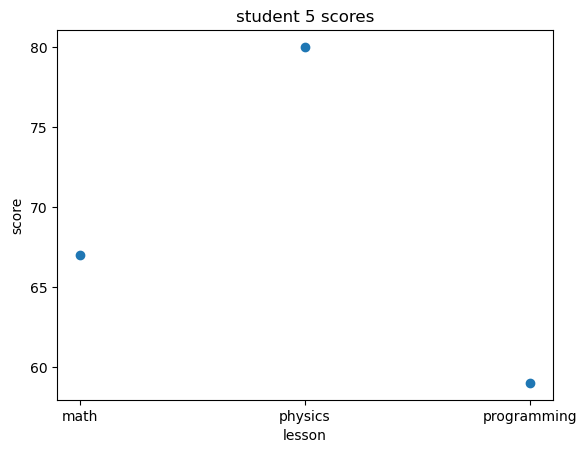

In [39]:
graph_student_id(student_rdata_float, 5)

# 14. Plotting Scores in a Lesson

In [40]:
def graph_lesson(data_matrix:np.array, lesson:str) -> float:
    '''
    Plots the scores of all students in a user-defined lesson.
    '''
    dict1 = {'math':1, 'physics':2, 'programming':3}
    try:
        plt.scatter(data_matrix[:, 0], data_matrix[:, dict1[lesson]])
        plt.xlabel('student_id')
        plt.ylabel(lesson)
        plt.xticks(np.arange(1, len(data_matrix) + 1))
        plt.title(lesson + ' scores')
        plt.show()
    except :
        print('The', lesson, 'does not exist among lessons.')

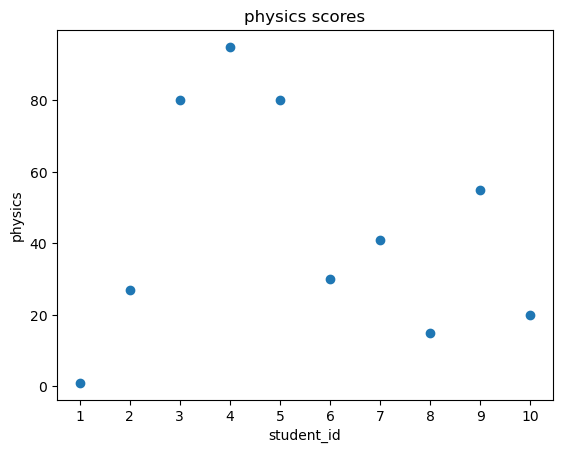

In [41]:
graph_lesson(student_rdata_float, 'physics')

In [42]:
def menu():
    while True:
        try:
            user_file_name = input('Enter filename:')
            user_student_number = int(input('Enter number of students:'))
            break
        except:
            print('Wrong number!')
            
    create_student_file(user_file_name, user_student_number)
    user_student_rdata = read_data(user_file_name)
    user_student_rdata_float = convert_to_float(user_student_rdata)
    
    while True:
        try:
            user_mode = int(input('''Select a mode:
            1: Analytics for student
            2: Analytics for lesson
            '''))
            if user_mode != 1 and user_mode != 2:
                print('Wrong number!')
                continue
            else:
                break
        except:
            print('Wrong number!')

    if user_mode == 1:
        while True:
            try:
                user_student_ID = int(input('Enter student ID:'))
                if user_student_ID < 1 or user_student_ID > user_student_number:
                    print('Out of range')
                    continue
                else:
                    break
            except:
                print('Wrong number!')
        
        print('The mean value of the scores of student' , user_student_ID, 'is', man_mean_student_id(user_student_rdata_float, user_student_ID))
        print('The median value of the scores of student', user_student_ID, 'is', man_median_student_id(user_student_rdata_float, user_student_ID))
        print('The variance value of the scores of student', user_student_ID, 'is', man_variance_student_id(user_student_rdata_float, user_student_ID))
        graph_student_id(user_student_rdata_float, user_student_ID)
        
    if user_mode == 2:
        while True:
            user_lesson = input('Enter one of the lessons math, physics or programming')
            if  not user_lesson in ['math', 'physics', 'programming']:
                print('Wrong lesson!')
                continue
            else:
                break
        
        print('The mean value of the scores in lesson', user_lesson, 'is', man_mean_lesson(user_student_rdata_float, user_lesson))
        print('The median value of the scores in lesson', user_lesson, 'is', man_median_lesson(user_student_rdata_float, user_lesson))
        print('The variance value of the scores in lesson', user_lesson, 'is', man_variance_lesson(user_student_rdata_float, user_lesson))
        graph_lesson(user_student_rdata_float, user_lesson)            
            
            
      

In [ ]:
menu()